In [53]:
import pandas as pd

In [54]:
data_eda = pd.read_csv('data/index_data.csv')

In [55]:
for i in data_eda["conm"].unique():
    print(i)

S&P Industrials-Wed
S&P 500 Ex-Financials, Real Estate, Utilities and Transportation Index
American Stock Exchange Ind
S&P 500 Comp-Ltd
Dow Jones Industrials-30 Stk
Dow Jones Transportation-20
Dow Jones Utilities-15 Stk
Nasdaq Index Composite
NY Stock Exchange-Composite
S&P/TSX Composite Index
Value Line Composite
Value Line Industrial
Russell 3000 Growth (Bridge)
Russell 3000 Value (Bridge)
Russell Top 200
Russell Top 200 Growth
Russell Top 200 Value
Russell 2000 Value (Bridge)
AMEX - Airline
AMEX - Computer Technology
Russell 2000 Growth (Bridge)
AMEX - Biotechnology Index
Nasdaq Financial
KBW BANK INDEX
PHLX GOLD SILVER INDEX
PHLX SEMICONDUCTOR INDEX
TSX 100 Index
TSX 200 Index
S&P/TSX COMPOSITE TR
PHLX UTILITY INDEX
Value Line Utilities
Dow Jones Wilshir 5000 Cmpst
Nasdaq 100
AMEX Intl Market  -Adr
AMEX - Reduced Value Pharm
S&P 500 Comp-Wed
Nasdaq National Market Comp
S&P Utilities
S&P Transportation
High Grade Common
Low Priced Common
Oil Composite
Retail Stores Composite
S&P Fin

In [56]:
tic_list = ["MET.I3", "OIG.I", "ENE.I", "MET.I","I0003", "I0048", "I0049", "I0050", "I0051", "I0052", "I0053", "I0054", "I0055", "I0056", "I0057", "I0058", "I0059", "I0060", "I0061", "I0062", "I0063", "I0064", "I0065", "I0066"]

In [57]:
tic_list

['MET.I3',
 'OIG.I',
 'ENE.I',
 'MET.I',
 'I0003',
 'I0048',
 'I0049',
 'I0050',
 'I0051',
 'I0052',
 'I0053',
 'I0054',
 'I0055',
 'I0056',
 'I0057',
 'I0058',
 'I0059',
 'I0060',
 'I0061',
 'I0062',
 'I0063',
 'I0064',
 'I0065',
 'I0066']

## 데이터 설명
- tic : 거래심볼
- datadate : 데이터 날짜
- gvkeyx : global index key
- conm : Index name
- dvpsxd : 지수 구성 종목의 보통주에 대한 배당금의 총액
- newnum : 현재 거래일의 지수 구성 요소수
- oldnum : 이전 거래일의 지수 구성 항목수 
- prccd : 해당 증권의 당일 종가, 거래량이 없는 매수 매도 가격의 경우 종가가 거래량이 포함된 마지막 거래 종가를 나타냄, 매수 매도 가격은 최고/최저 범위 밖에서 종가 형성 가능
- prccddiv : 지수의 일일 종가 수익률 가격 상승과 일일 배당금 재투자, 재투자된 배당금에 지급된 배당금의 복리효과 반영함.
- prccddivn : 지수의 일일 종가 수익률로 가격 상승과 세금을 제한후 순 배당을 재투자한 경우를 가정함.
- prchd : 거래일의 최고 거래 가격을 나타냄
- PRCLD : 매수 / 매도 책정의 경우 거래일의 가장 낮은 거래 가격을 나타냄. 장 마감전 마지막 입찰가를 나타냄. 매수 매도 가격 차이가 최신 매도 가격의 50%보다 큰 경우 이전 입찰 가격을 타나냄

In [58]:
using_data = data_eda[data_eda["tic"].isin(tic_list)]

In [59]:
using_data = using_data.sort_values(by=["datadate"])

In [60]:
using_data.reset_index(drop=True, inplace=True)

In [61]:
unique_pairs = using_data[['tic', 'conm']].drop_duplicates().reset_index(drop=True)

In [62]:
mapping_dict = unique_pairs.set_index('tic')['conm'].to_dict()

In [63]:
tic_mapping = {'I0003': 'SP500',
 'MET.I3': 'Gold',
 'ENE.I': 'Energy',
 'MET.I': 'Metals_Mining',
 'OIG.I': 'Oil_Gas_Consumable_Fuels',
 'I0063': 'Sweden',
 'I0059': 'Netherlnd',
 'I0049': 'Austria',
 'I0058': 'Mexico',
 'I0057': 'Malaysia',
 'I0062': 'Spain',
 'I0061': 'Singapore',
 'I0054': 'Hong Kong',
 'I0048': 'Australia',
 'I0051': 'Canada',
 'I0056': 'Japan',
 'I0055': 'Italy',
 'I0053': 'Germany',
 'I0052': 'France',
 'I0064': 'Switzrlnd',
 'I0066': 'Belgium',
 'I0065': 'Utd_Kgdm'}

In [64]:
using_data["tic_map"] = using_data.tic.map(tic_mapping, na_action='ignore')

In [65]:
data_start = "1999-01-04"

In [66]:
index_data = using_data[using_data["datadate"] >=data_start]

In [67]:
index_data.reset_index(drop=True, inplace=True)

In [69]:
# 전체 티커 목록
all_tickers = index_data["tic_map"].unique()

# 각 티커별 보유 날짜 집합
date_sets = {
    ticker: set(index_data[index_data["tic_map"] == ticker]["datadate"])
    for ticker in all_tickers
}

# 모든 티커가 공통으로 가진 날짜 (교집합)
common_dates = set.intersection(*date_sets.values())

# 누락된 날짜 확인: 전체 날짜에서 공통 날짜 빼기
all_dates = set(index_data["datadate"].unique())
missing_dates = sorted(all_dates - common_dates)

print("✅ 삭제 대상 날짜 목록:")
print(missing_dates)


✅ 삭제 대상 날짜 목록:
['1999-01-26', '1999-02-11', '1999-02-12', '1999-06-04', '1999-10-20', '2000-03-06', '2006-09-28', '2012-10-19']


In [76]:
# 모든 티커가 존재하는 날짜 교집합
valid_dates = set.intersection(*[
    set(index_data[index_data["tic_map"] == i]["datadate"]) 
    for i in index_data.tic_map.unique()
])

# 그 날짜만 필터링
index_data = index_data[index_data["datadate"].isin(valid_dates)]


In [78]:
subset = index_data[index_data.tic_map == "SP500"].copy()


In [79]:
tic_mapping.values()

dict_values(['SP500', 'Gold', 'Energy', 'Metals_Mining', 'Oil_Gas_Consumable_Fuels', 'Sweden', 'Netherlnd', 'Austria', 'Mexico', 'Malaysia', 'Spain', 'Singapore', 'Hong Kong', 'Australia', 'Canada', 'Japan', 'Italy', 'Germany', 'France', 'Switzrlnd', 'Belgium', 'Utd_Kgdm'])

In [80]:
import matplotlib.pyplot as plt
import numpy as np

In [81]:
# for i in tic_mapping.values():
#     subset = index_data[index_data.tic_map == i].copy()

#     print("High price 이상치 상위 5개:")
#     print(subset[['datadate', 'tic_map', 'prchd']].sort_values('prchd', ascending=False).head(5))

#     print("\nClose price 이상치 상위 5개:")
#     print(subset[['datadate', 'tic_map', 'prccd']].sort_values('prccd', ascending=False).head(5))

#     print("\nLow price 이상치 상위 5개:")
#     print(subset[['datadate', 'tic_map', 'prcld']].sort_values('prcld', ascending=False).head(5))


In [82]:
def find_all_price_jumps(df, price_col='prccd', threshold=2.0):
    jump_all = []

    for name, group in df.groupby('tic_map'):
        group = group.sort_values('datadate').copy()
        group['datadate'] = pd.to_datetime(group['datadate'])
        group['prev_price'] = group[price_col].shift(1)
        group['ratio'] = group[price_col] / group['prev_price']

        # 변화 비율이 너무 큰 경우 (상승 or 하락)
        jump_mask = (group['ratio'] > threshold) | (group['ratio'] < 1 / threshold)
        jumps = group.loc[jump_mask, ['tic_map', 'datadate', 'prccd', 'prev_price', 'ratio']]
        jump_all.append(jumps)

    return pd.concat(jump_all).sort_values(['tic_map', 'datadate']).reset_index(drop=True)


In [83]:
jumps_all = find_all_price_jumps(index_data, price_col='prccd', threshold=2.0)


In [84]:
index_data["tic_map"].unique()

array(['Metals_Mining', 'Netherlnd', 'Gold', 'Malaysia', 'Austria',
       'Germany', 'Mexico', 'Switzrlnd', 'Sweden', 'Singapore', 'Canada',
       'Oil_Gas_Consumable_Fuels', 'Spain', 'France', 'Utd_Kgdm',
       'Hong Kong', 'Belgium', 'Australia', 'Italy', 'Energy', 'SP500',
       'Japan'], dtype=object)

In [85]:
jumps_all

,tic_map,datadate,prccd,prev_price,ratio
0,Italy,2000-06-30,61.330,25.410,2.413617
1,Italy,2000-07-03,25.870,61.330,0.421816
2,Italy,2016-11-07,22.159,10.908,2.031445
3,Japan,2016-11-07,49.568,12.419,3.991304
4,Malaysia,2016-11-07,31.584,7.914,3.990902
5,Singapore,2016-11-07,20.747,10.342,2.006092
6,Utd_Kgdm,2016-11-07,29.851,14.822,2.013966


In [86]:
subset = index_data[index_data["tic_map"]=="Belgium"]
subset = subset.set_index('datadate').sort_index()

In [87]:
import numpy as np
import pandas as pd

# 1. 저가 이상치 정제 함수
def clean_low_price(df, price_col='prcld', ref_col='prccd',
                    low_thresh_ratio=0.5, replace_with='ref'):
    df = df.copy()
    mask = df[price_col] < df[ref_col] * low_thresh_ratio
    if replace_with == 'nan':
        df.loc[mask, price_col] = np.nan
    elif replace_with == 'ref':
        df.loc[mask, price_col] = df.loc[mask, ref_col]
    return df

# 2. 고가 이상치 정제 함수
def clean_high_price(df, price_col='prchd', ref_col='prccd',
                     threshold_ratio=1.5, replace_with='ref'):
    df = df.copy()
    mask = df[price_col] > df[ref_col] * threshold_ratio
    if replace_with == 'nan':
        df.loc[mask, price_col] = np.nan
    elif replace_with == 'ref':
        df.loc[mask, price_col] = df.loc[mask, ref_col]
    return df

# 3. Italy 수동 이상치 + 저가 정제
def clean_italy(df):
    df = df.copy()
    italy = df[df['tic_map'] == 'Italy'].copy()
    italy['datadate'] = pd.to_datetime(italy['datadate'])

    # 수동 보정 (2000-06-30)
    mask = italy['datadate'] == '2000-06-30'
    before = italy.loc[italy['datadate'] == '2000-06-29', 'prccd'].values[0]
    after = italy.loc[italy['datadate'] == '2000-07-03', 'prccd'].values[0]
    corrected = (before + after) / 2
    italy.loc[mask, 'prccd'] = corrected
    italy.loc[mask, 'prchd'] = corrected

    # 저가 정제
    italy = clean_low_price(italy, price_col='prcld', ref_col='prccd',
                            low_thresh_ratio=0.5, replace_with='ref')
    return italy

# 4. 리버스 스플릿 스케일 적용 함수
def apply_reverse_split_scaling(df, cutoff='2016-11-07', scale=1.0):
    df = df.copy()
    df['datadate'] = pd.to_datetime(df['datadate'])

    before = df[df['datadate'] < cutoff].copy()
    after = df[df['datadate'] >= cutoff].copy()

    if not before.empty:
        before[['prccd', 'prchd', 'prcld']] *= scale

    return pd.concat([before, after]).sort_values('datadate').reset_index(drop=True)

# 5. 전체 정제 함수 (이탈리아, 국가별 스케일 포함)
def clean_all_index_data(df):
    df = df.copy()
    df['datadate'] = pd.to_datetime(df['datadate'])

    cleaned_all = []

    # ✅ 국가별 리버스 스플릿 스케일링 비율
    split_scales = {
        'Japan': 4.0,
        'Malaysia': 4.0,
        'Singapore': 2.0,
        'Utd_Kgdm': 2.0
    }

    for name, group in df.groupby('tic_map'):
        group = group.sort_values('datadate').copy()

        if name == 'Italy':
            cleaned = clean_italy(group)

        elif name in split_scales:
            group = apply_reverse_split_scaling(group, cutoff='2016-11-07', scale=split_scales[name])
            group = clean_low_price(group, price_col='prcld', ref_col='prccd',
                                    low_thresh_ratio=0.5, replace_with='ref')
            group = clean_high_price(group, price_col='prchd', ref_col='prccd',
                                     threshold_ratio=1.5, replace_with='ref')
            cleaned = group

        else:
            group = clean_low_price(group, price_col='prcld', ref_col='prccd',
                                    low_thresh_ratio=0.5, replace_with='ref')
            group = clean_high_price(group, price_col='prchd', ref_col='prccd',
                                     threshold_ratio=1.5, replace_with='ref')
            cleaned = group

        cleaned_all.append(cleaned)

    return pd.concat(cleaned_all).reset_index(drop=True)
index_data_cleaned = clean_all_index_data(index_data)


SP500


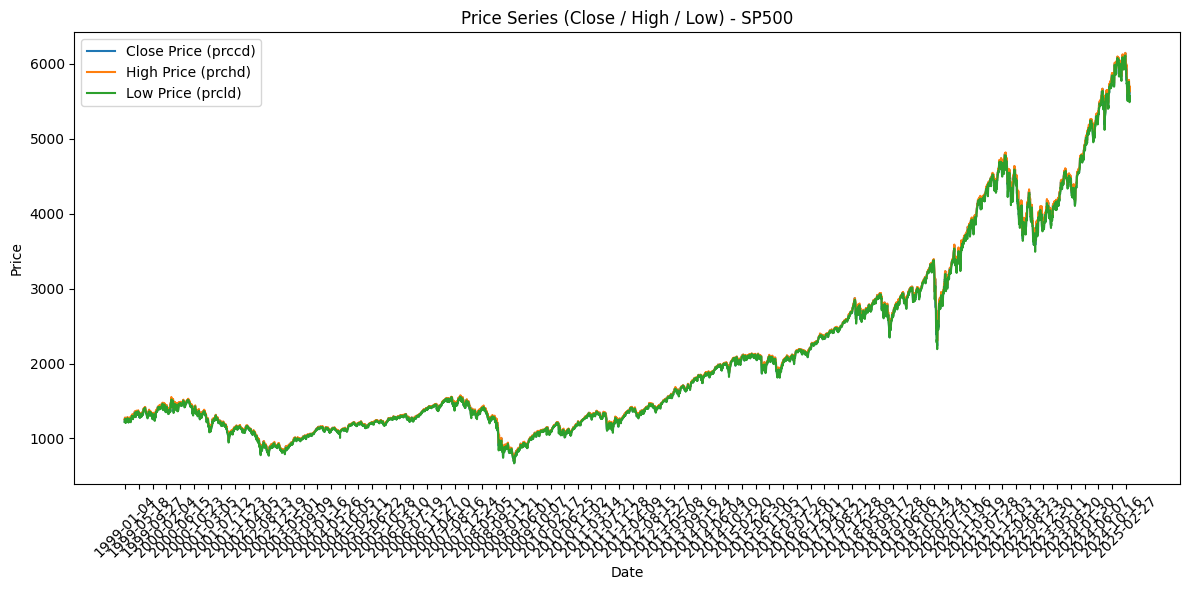

Gold


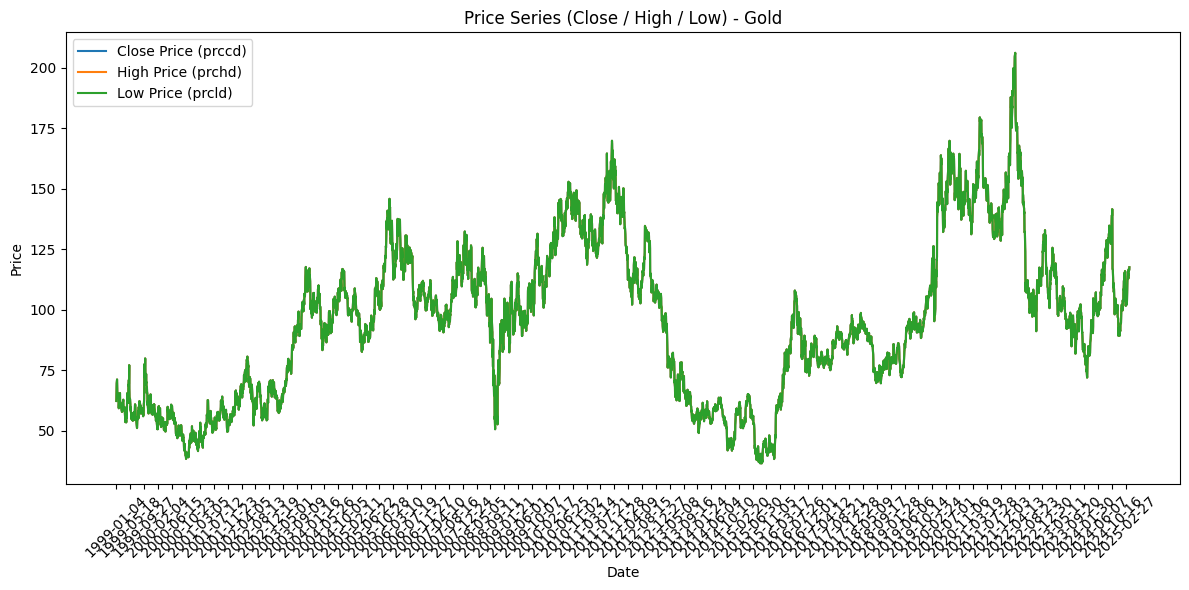

Energy


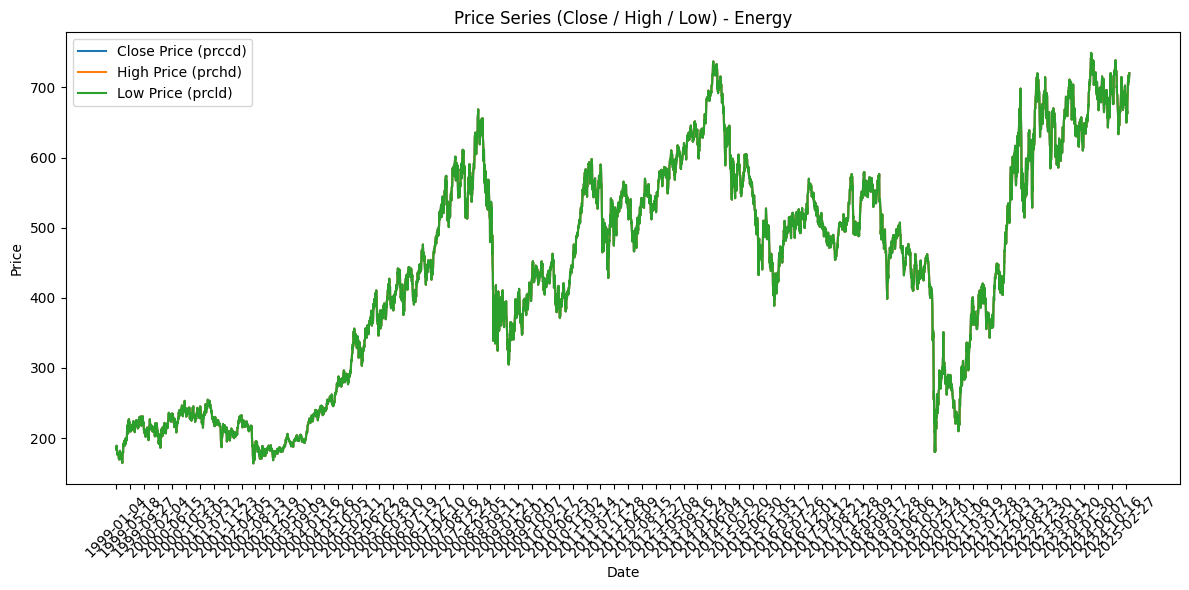

Metals_Mining


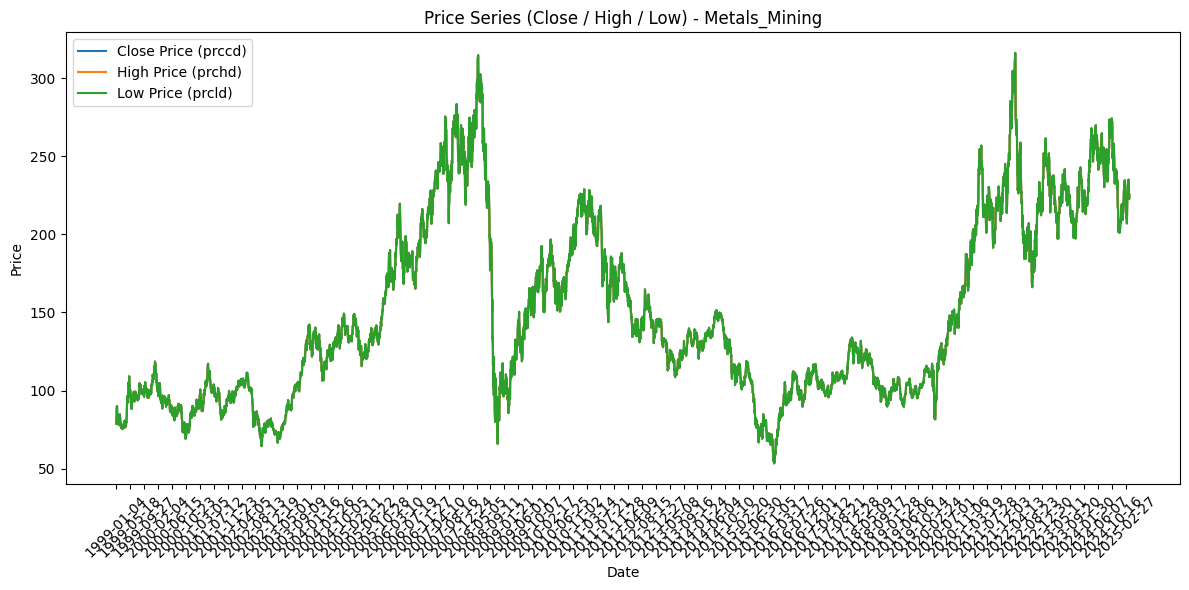

Oil_Gas_Consumable_Fuels


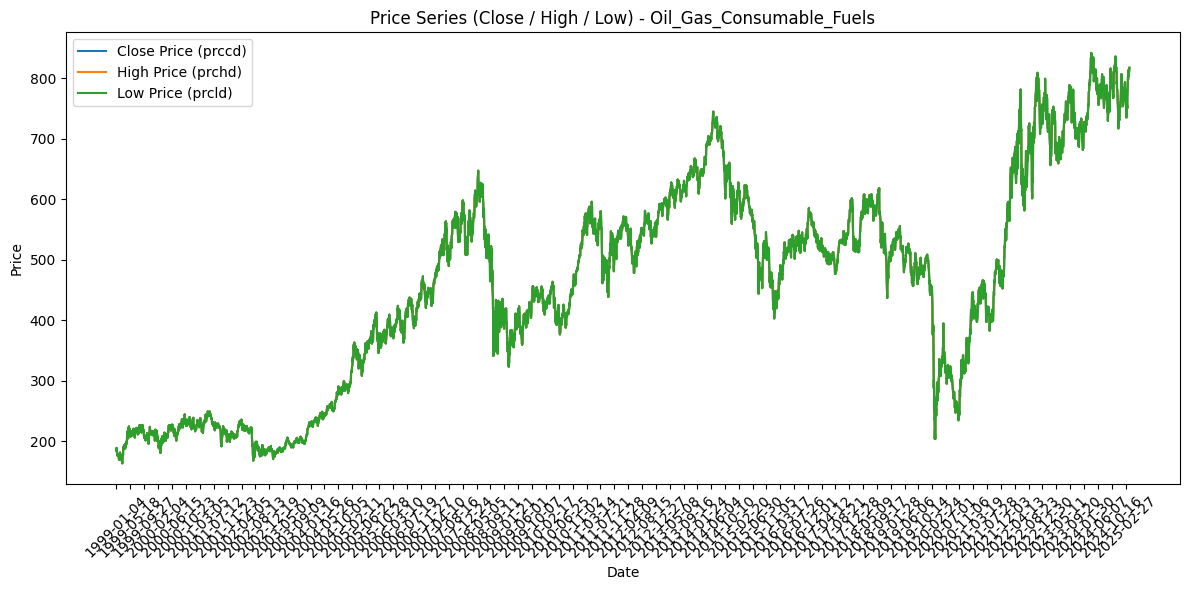

Sweden


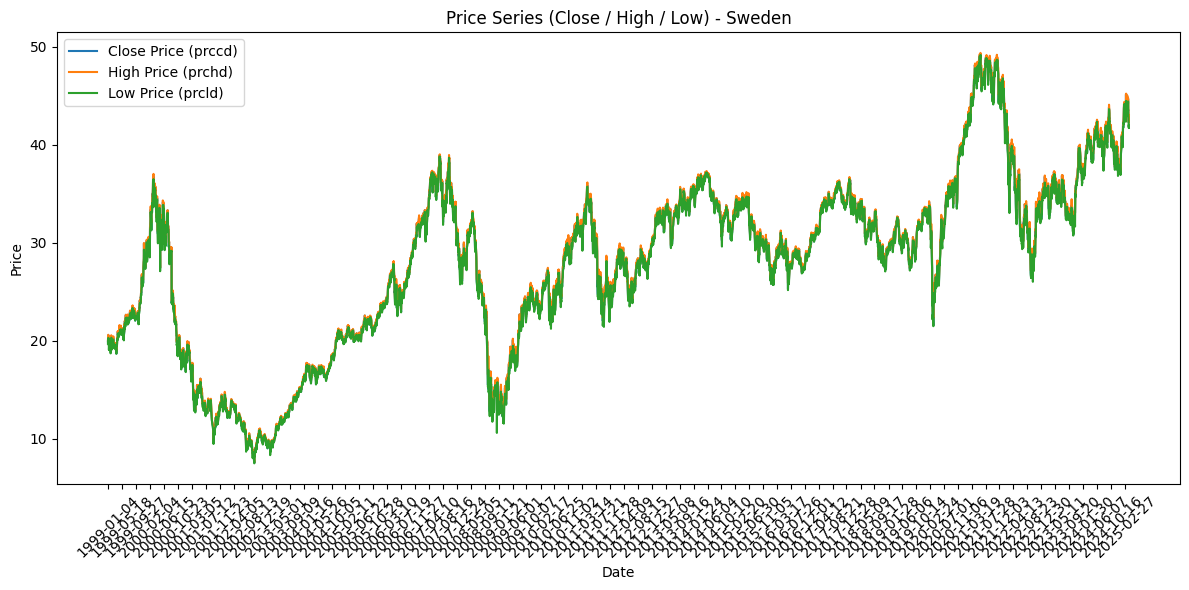

Netherlnd


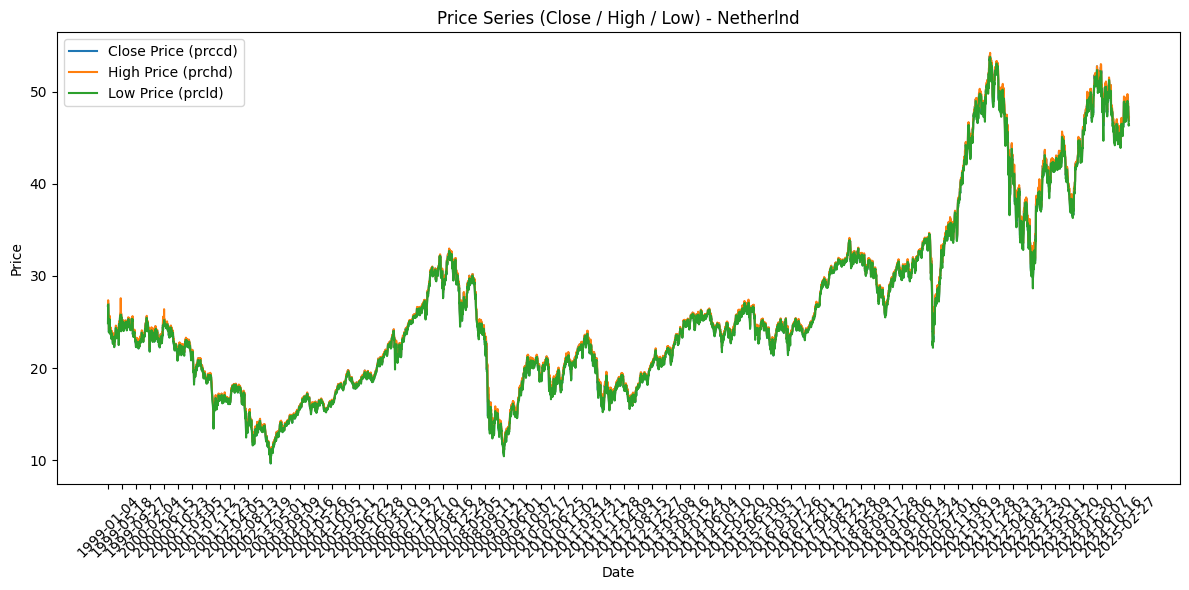

Austria


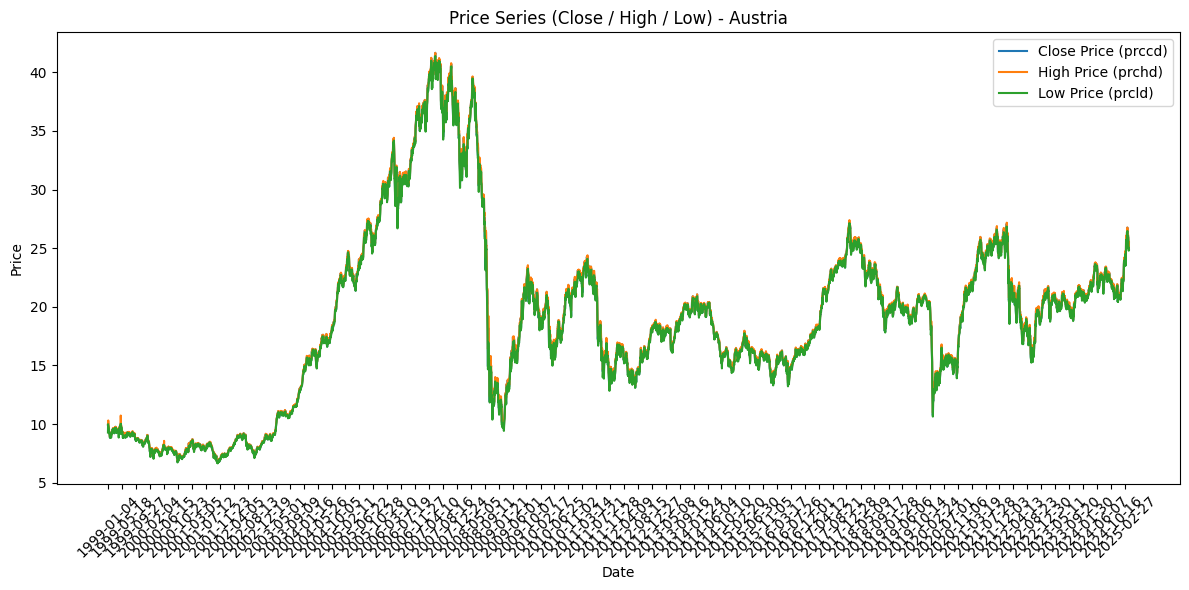

Mexico


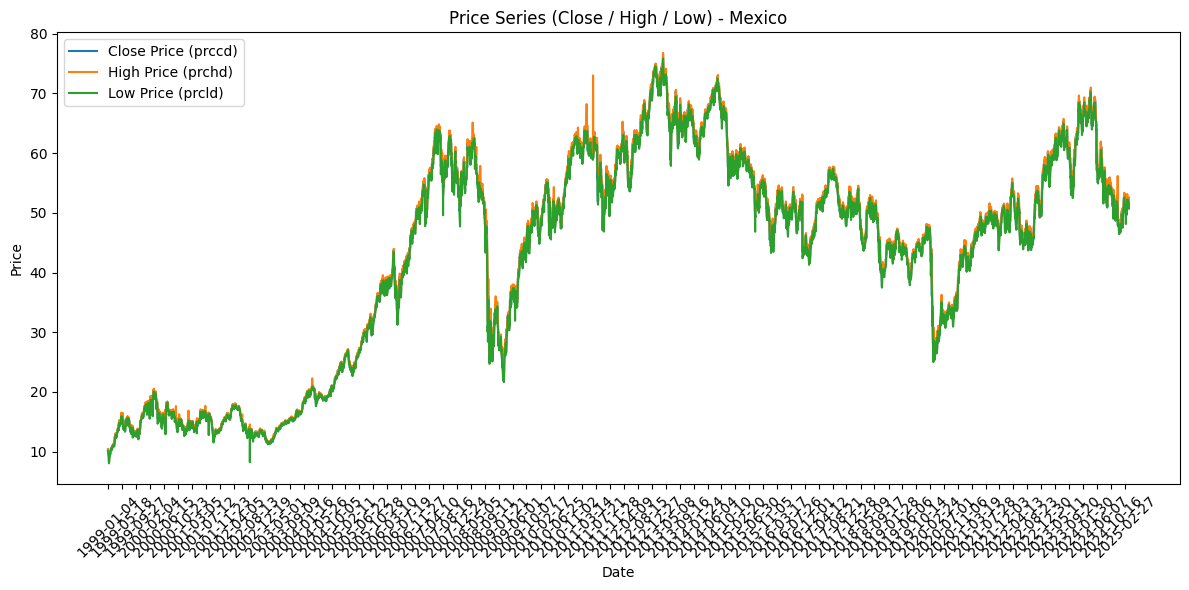

Malaysia


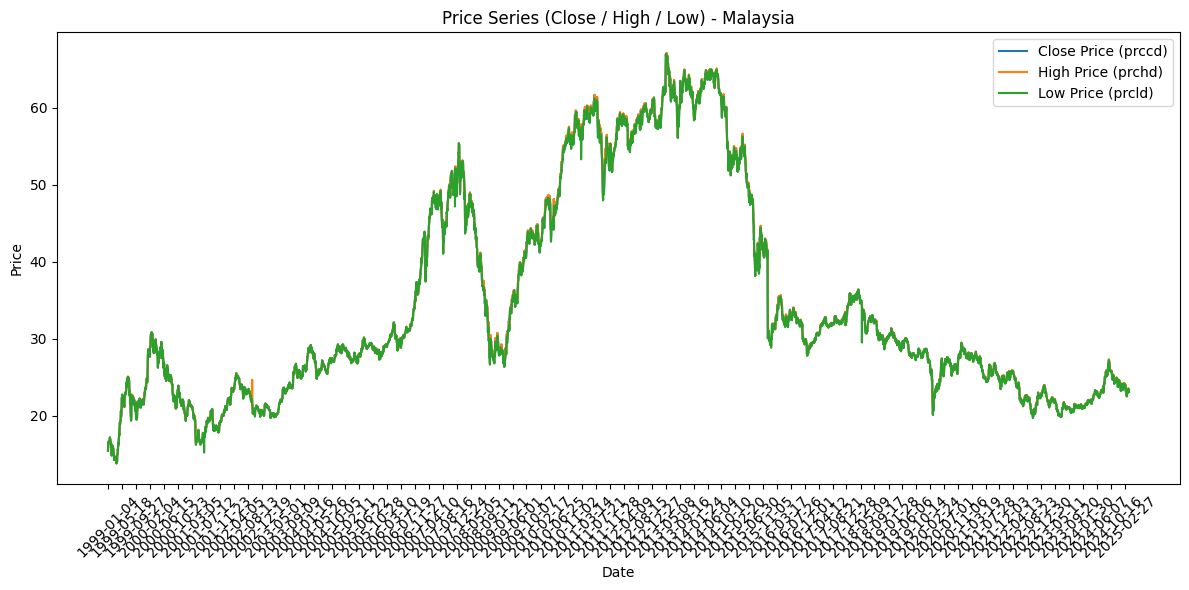

Spain


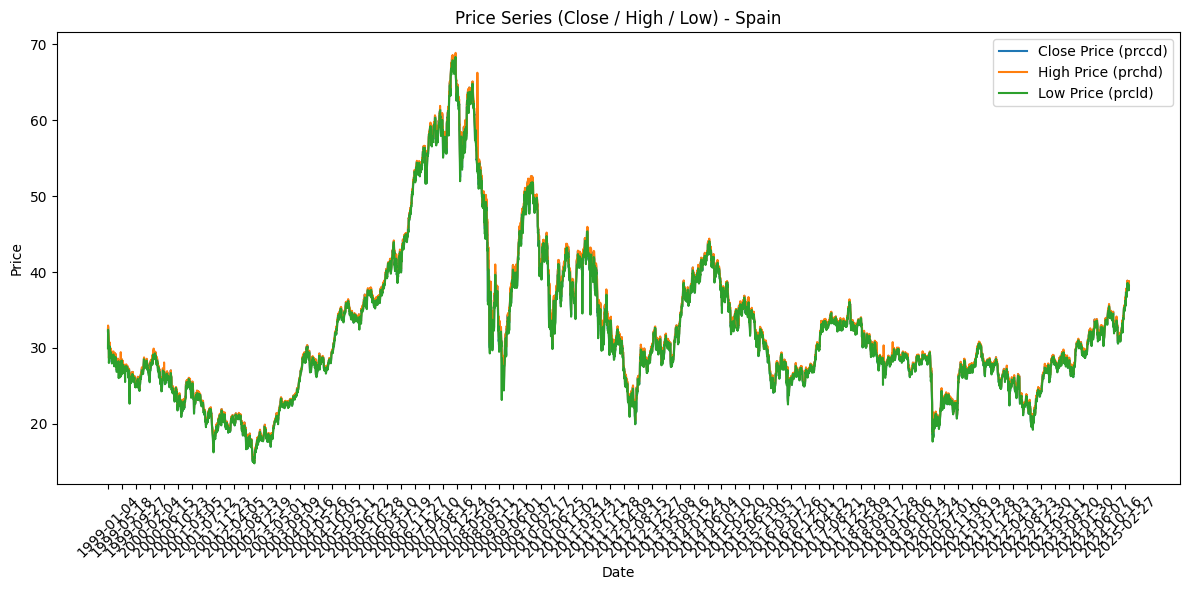

Singapore


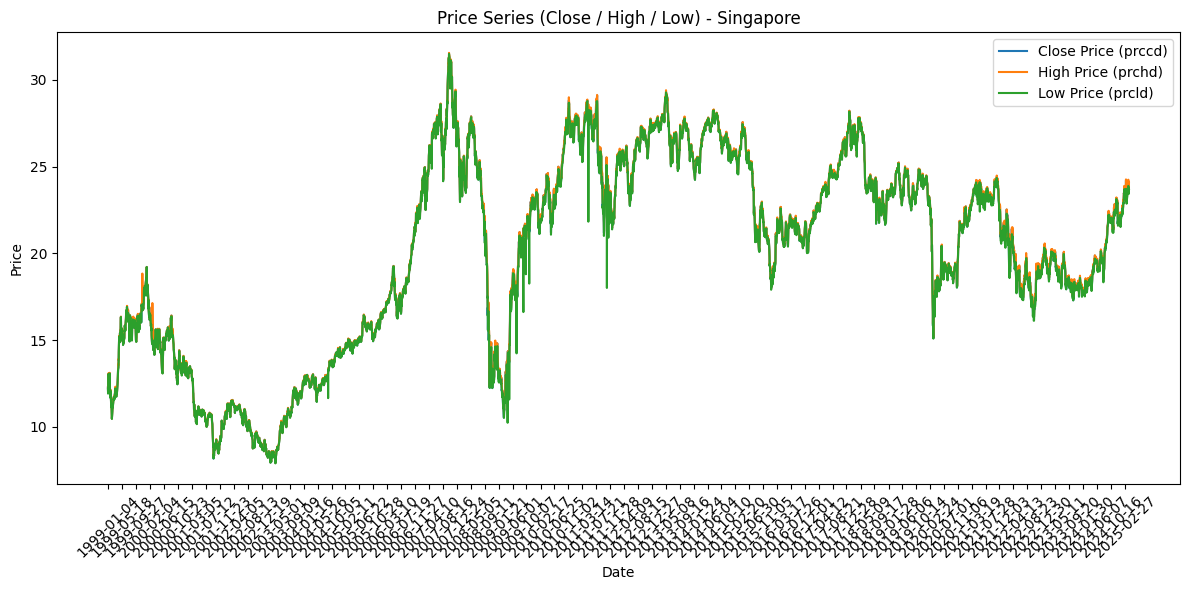

Hong Kong


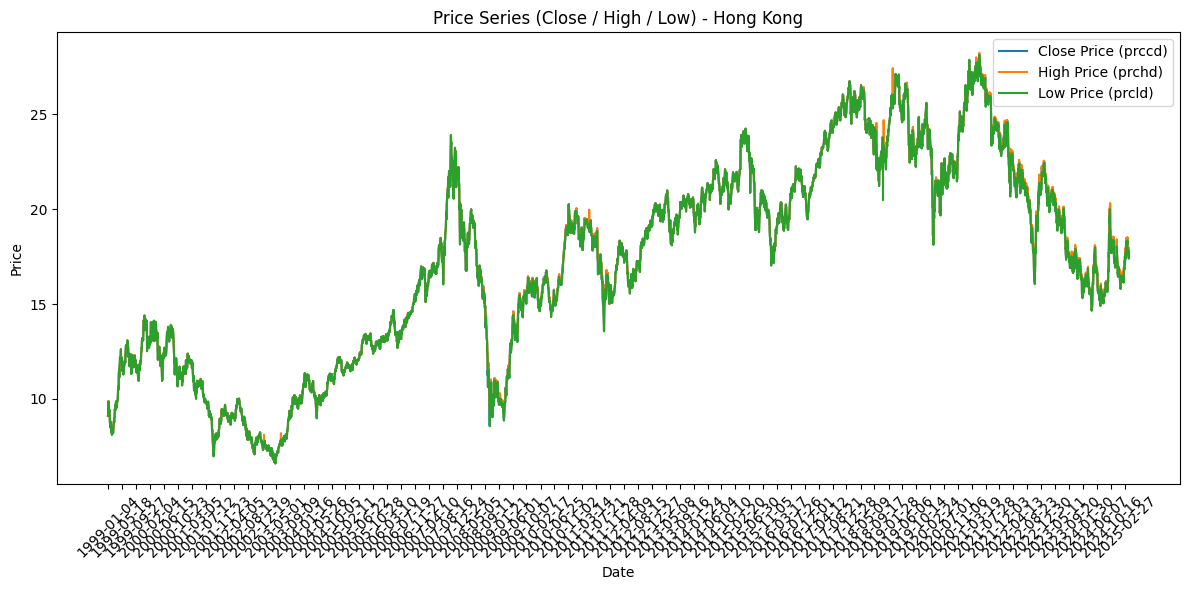

Australia


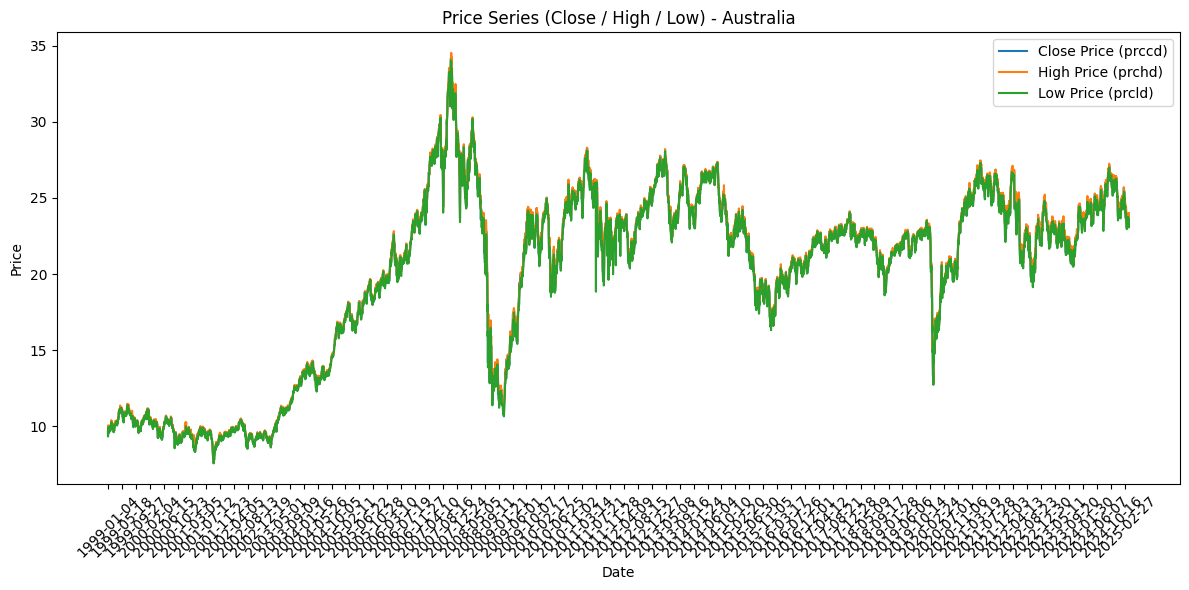

Canada


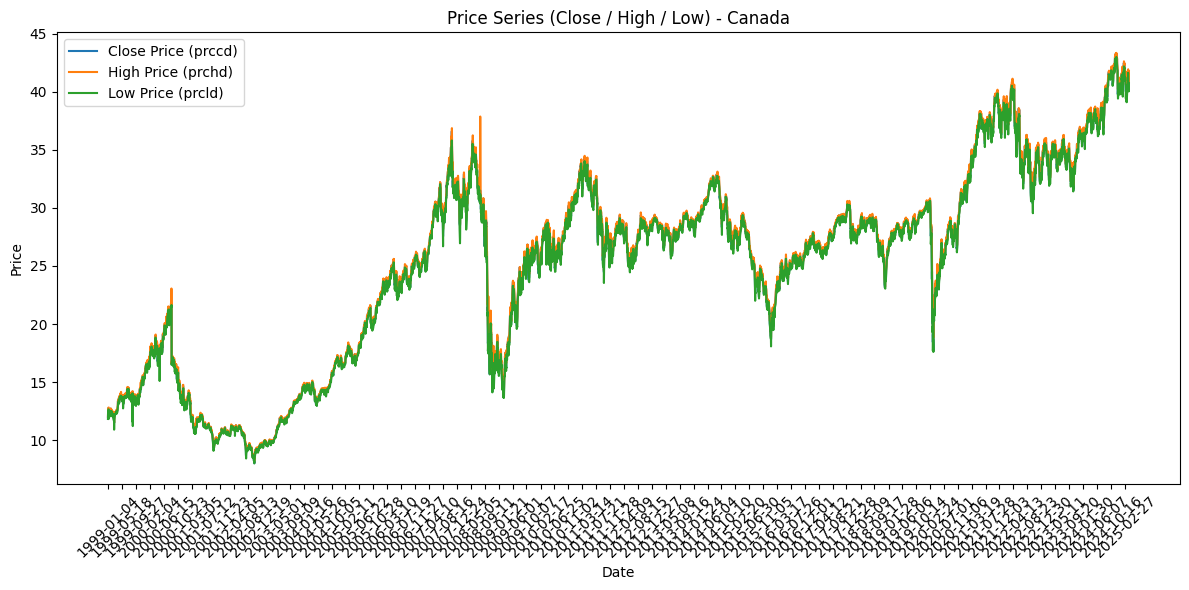

Japan


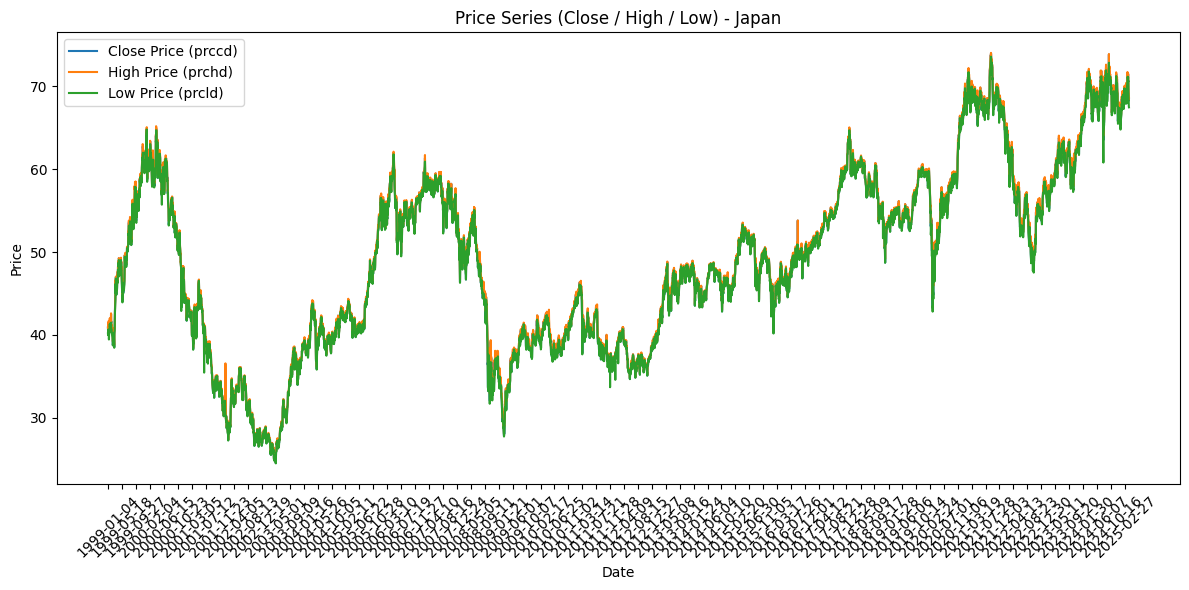

Italy


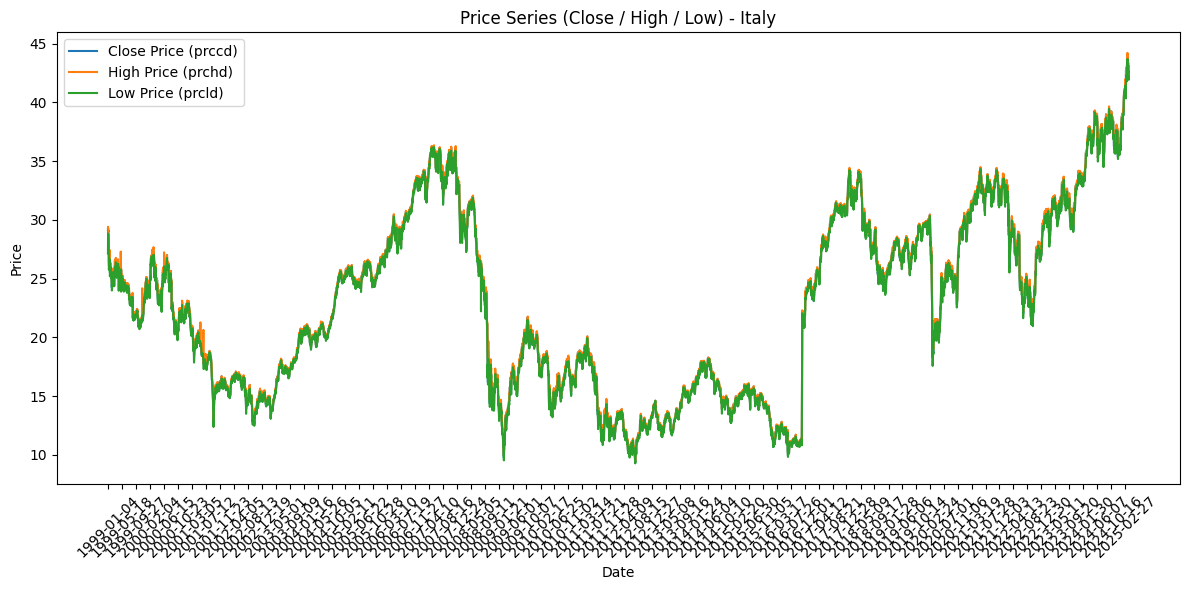

Germany


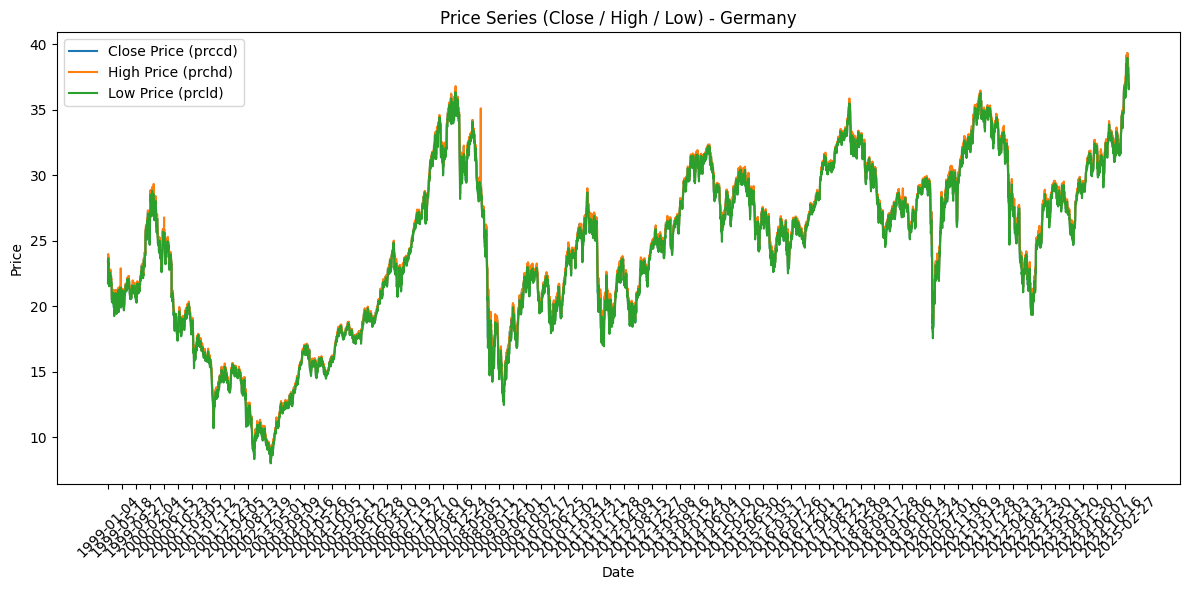

France


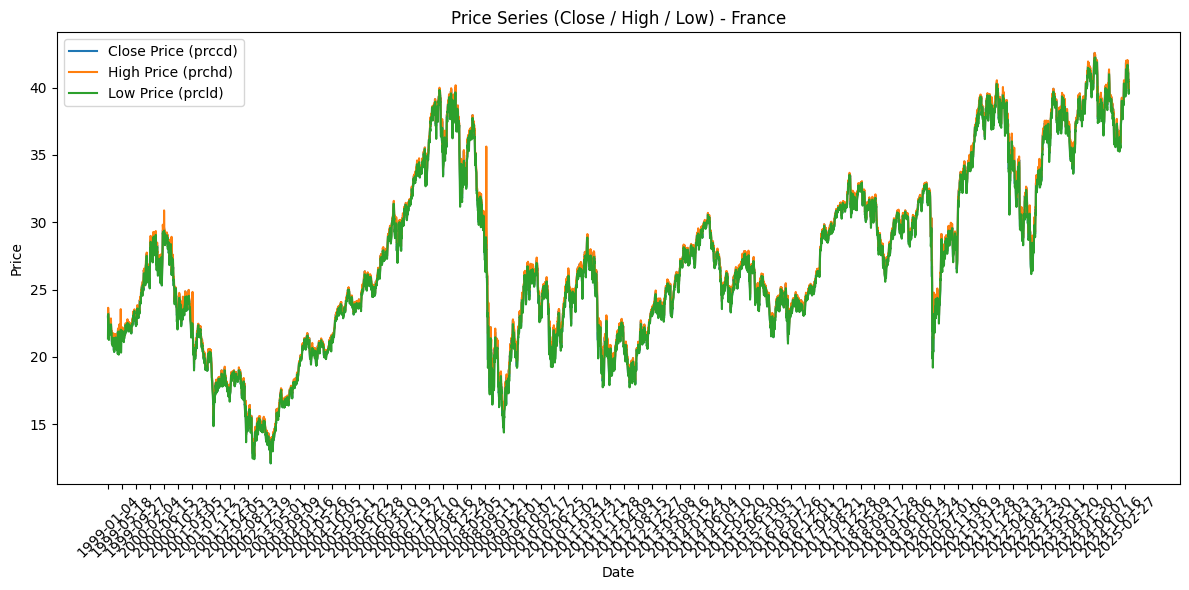

Switzrlnd


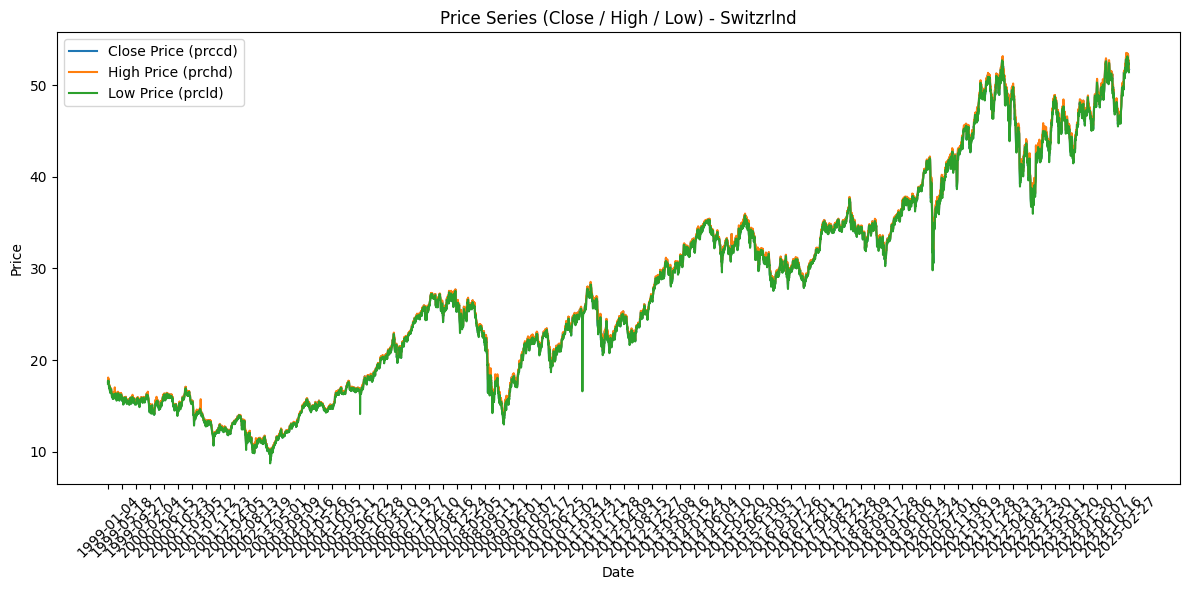

Belgium


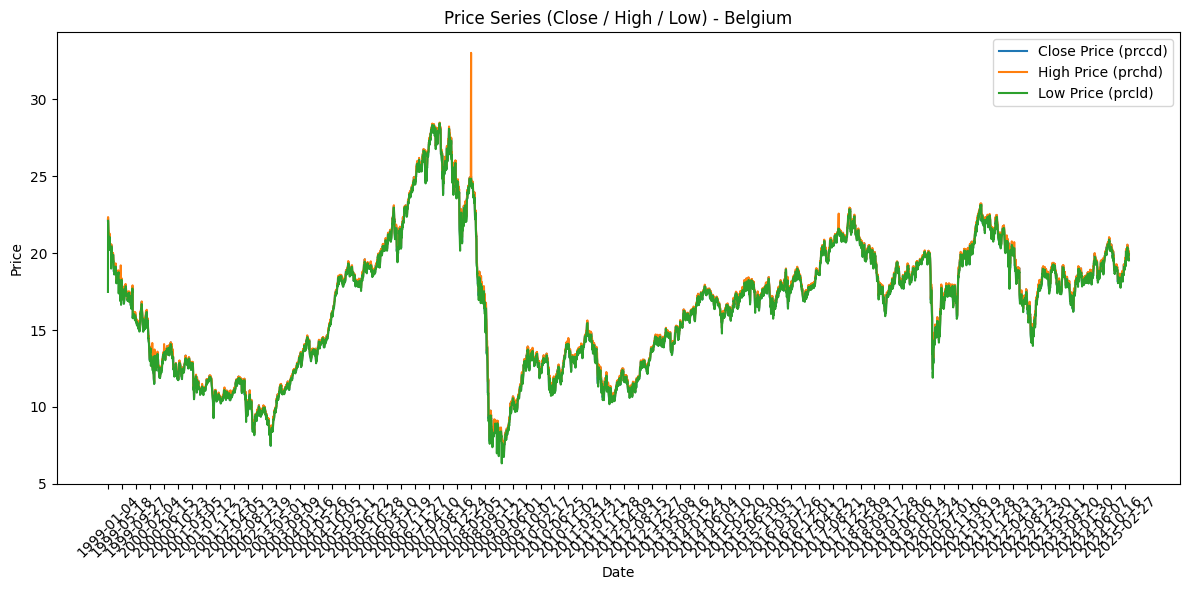

Utd_Kgdm


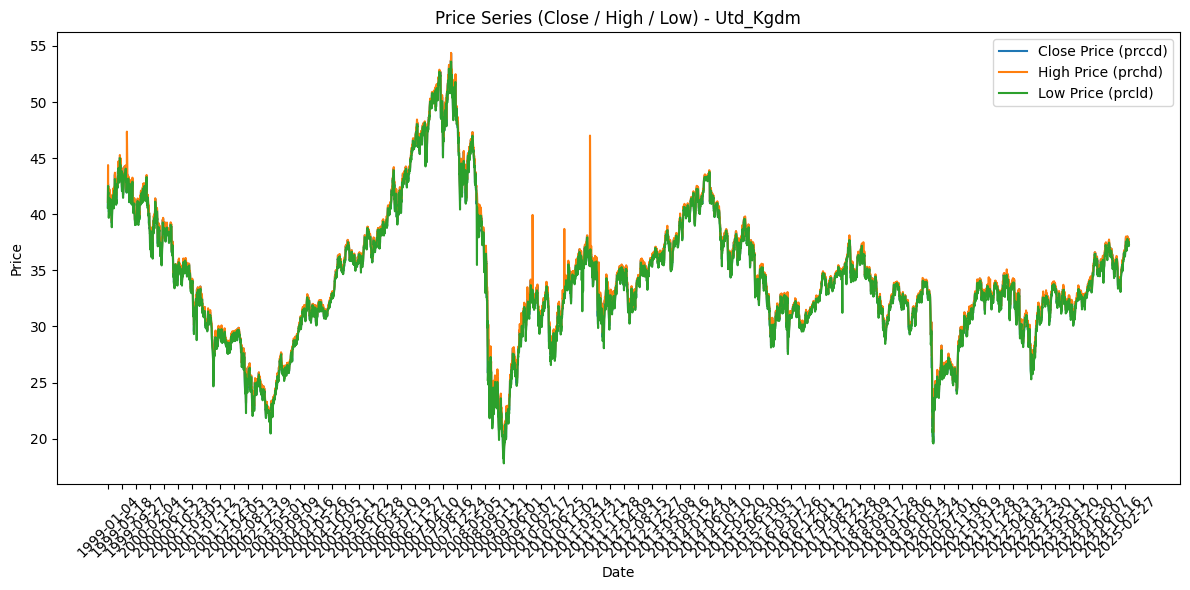

In [88]:
for i in tic_mapping.values():
    print(i)

    subset = index_data_cleaned[index_data_cleaned.tic_map == i].copy()
    subset = subset.sort_values('datadate')

    # 20일마다 datadate 추출 (인덱스 기반 또는 실제 날짜 기준)
    tick_idx = subset.index[::90]  # 20개마다 한 번
    tick_labels = subset['datadate'].iloc[::90]

    plt.figure(figsize=(12, 6))
    plt.plot(subset['datadate'], subset['prccd'], label='Close Price (prccd)')
    plt.plot(subset['datadate'], subset['prchd'], label='High Price (prchd)')
    plt.plot(subset['datadate'], subset['prcld'], label='Low Price (prcld)')

    plt.title(f'Price Series (Close / High / Low) - {i}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.xticks(tick_labels, rotation=45)  # x축 눈금 설정
    plt.legend()
    plt.tight_layout()
    plt.show()


In [89]:
index_data_cleaned

,tic,datadate,gvkeyx,conm,dvpsxd,newnum,oldnum,prccd,prccddiv,prccddivn,prchd,prcld,tic_map
0,I0048,1999-01-04,132838,Webs Index Fd-Iopv Australia,NaN,NaN,NaN,9.610,NaN,NaN,9.630,9.510,Australia
1,I0048,1999-01-05,132838,Webs Index Fd-Iopv Australia,NaN,NaN,NaN,9.520,NaN,NaN,9.560,9.330,Australia
2,I0048,1999-01-06,132838,Webs Index Fd-Iopv Australia,NaN,NaN,NaN,9.770,NaN,NaN,9.800,9.670,Australia
3,I0048,1999-01-07,132838,Webs Index Fd-Iopv Australia,NaN,NaN,NaN,10.020,NaN,NaN,10.070,9.930,Australia
4,I0048,1999-01-08,132838,Webs Index Fd-Iopv Australia,NaN,NaN,NaN,9.860,NaN,NaN,9.880,9.780,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145085,I0065,2025-03-27,132960,Webs Index Fd-Iopv Utd Kgdm,NaN,NaN,NaN,37.716,NaN,NaN,37.781,37.434,Utd_Kgdm
145086,I0065,2025-03-28,132960,Webs Index Fd-Iopv Utd Kgdm,NaN,NaN,NaN,37.610,NaN,NaN,37.817,37.588,Utd_Kgdm
145087,I0065,2025-03-31,132960,Webs Index Fd-Iopv Utd Kgdm,NaN,NaN,NaN,37.463,NaN,NaN,37.518,37.153,Utd_Kgdm
145088,I0065,2025-04-01,132960,Webs Index Fd-Iopv Utd Kgdm,NaN,NaN,NaN,37.426,NaN,NaN,37.583,37.222,Utd_Kgdm


In [90]:
index_data_cleaned.sort_values(by=["datadate", "tic"], inplace=True)

In [91]:
index_data_cleaned.reset_index(drop=True, inplace=True)

In [92]:
index_data_cleaned.to_csv("select_index_data_cleaned.csv", index=False)